# This notebook contains heavy imports and calculations, please do not run on a regular CPU

(but for example on Colab)

<br>

# Cross-validation for a fine-tuned BERT model

### (extends the Day 3 afternoon notebook, *Training and Fine-Tuning BERT for Classification*)

Yesterday we fine-tuned [`jhu-clsp/mmBERT-small`](https://huggingface.co/jhu-clsp/mmBERT-small) on the `tweets_dataset` (`cardiffnlp/tweet_eval`, "offensive" subset) using **one** train/validation split, and judged the model on that single validation set.

A single split can be lucky or unlucky. **k-fold cross-validation** gives a more accurate picture. We cut the fine-tuning data into *k* equal parts, then train *k* times, each time holding out a different part for validation. We then look at the **average** score and at **how much it varies** between runs.

Here we run **4-fold cross-validation** on a small (2000-tweet) subset of the training data. The `test` set is not touched until the very end.

If you haven't run `first_full_pipeline.ipynb` yet, do that first so `tweets_dataset` exists on disk.

<br><br>

## **Import necessary Python libraries and modules**

Next, we will import necessary Python libraries and modules.

In [1]:
import os
import random
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils import compute_sample_weight
import torch
from torch.utils.data import Subset
from datasets import load_dataset, load_from_disk
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification



from collections import defaultdict

sns.set_theme(style='ticks', font_scale=1.2)

%matplotlib inline
import matplotlib.pyplot as plt

os.environ["WANDB_DISABLED"] = "true"

<br>

## **Read in data**

The next cell sets up **where the dataset and the fine-tuned model are stored**, and downloads the `tweets_dataset` (the `cardiffnlp/tweet_eval` "offensive" subset) the first time you run it. On Colab everything goes to a folder in your Google Drive, so it survives the session; running locally it uses a `data/` folder next to this notebook. The dataset already comes split into `train`, `validation`, and `test`, so we don't need to split it ourselves.

In [2]:
# --- Where the dataset and the fine-tuned model are stored --------------------
# Run this cell once. It works on Colab (stores everything in your Google Drive,
# so it survives the session) and locally. Safe to re-run: the dataset is only
# downloaded if it is not already on disk.

try:
    from google.colab import drive
    drive.mount('/content/drive')                            # you'll be asked to authenticate
    project_dir = '/content/drive/MyDrive/GESIS26_tweets'    # a folder in your Google Drive
except ImportError:
    project_dir = 'data'                                     # running locally, next to this notebook

os.makedirs(project_dir, exist_ok=True)
datadir = project_dir                                        # the dataset is loaded from here

dataset_path = os.path.join(datadir, 'tweets_dataset')
if os.path.isdir(dataset_path):
    print(f'Using existing dataset at {dataset_path}')
else:
    print(f'Downloading cardiffnlp/tweet_eval "offensive" -> {dataset_path}')
    load_dataset('cardiffnlp/tweet_eval', 'offensive').save_to_disk(dataset_path)

Mounted at /content/drive
Using existing dataset at /content/drive/MyDrive/GESIS26_tweets/tweets_dataset


The cell above re-downloads only if `tweets_dataset` is missing. If you already saved the dataset somewhere else, point `project_dir` at the folder that *contains* your `tweets_dataset` directory.

In [3]:
# Load the dataset prepared above and split each subset into texts (X) and integer labels (y).

tweets = load_from_disk(os.path.join(datadir, "tweets_dataset"))

train_tweets = tweets["train"].to_pandas()
# val_tweets = tweets["validation"].to_pandas() # Note: the validation set is not used in this notebook, since we are doing cross-validation on the training set. The test set (not the validation set) is then used for final evaluation after cross-validation is complete.
test_tweets = tweets["test"].to_pandas()

X_train, y_train = train_tweets['text'].to_list(), train_tweets['label'].to_list()
# X_val, y_val = val_tweets['text'].to_list(), val_tweets['label'].to_list()
X_test, y_test = test_tweets['text'].to_list(), test_tweets['label'].to_list()

In [4]:
print(f"We have {len(X_train)} train examples, and {len(X_test)} test examples.")

We have 11916 train examples, and 860 test examples.


## What we are about to do: 4-fold cross-validation

1. Take the **2000-tweet fine-tuning subset** (created a few cells below).
2. Split it into **4 equal folds**, keeping the offensive / non-offensive ratio the same in every fold (*stratified*).
3. Repeat 4 times. In round *i*:
   - train a **fresh** model on 3 folds (~1500 tweets),
   - validate it on the remaining fold (~500 tweets),
   - write down accuracy and macro-F1.
4. Report the **mean** of the 4 scores and their **spread** (standard deviation).

**Why a fresh model each round?** If we kept training the same model, it would gradually see every fold, and the validation scores would become too optimistic (data leakage).

You *never* touch the **test** set during cross-validation. It is used once, at the very end, on the final model.

**Cost:** cross-validation trains the model 4 times, so it takes roughly 4x as long as a single fine-tuning run.

We will be using the `AutoTokenizer.from_pretrained()` module from HuggingFace library to encode our texts. This module will handle all the encoding for us, including breaking word tokens into word pieces, truncating to 200 tokens, and adding padding and special BERT tokens.

In [5]:
# Ideally, we want to run our code on CUDA (NVIDIA GPUs using the program management system) or MPS (Apple Silicon GPUs).

# Check if there is a GPU available...
if torch.cuda.is_available():
    # Tell PyTorch to use the CUDA GPU.
    device_name = torch.device("cuda")
    print('There are %d CUDA GPU(s) available.' % torch.cuda.device_count())
    print('We will use the CUDA GPU:', torch.cuda.get_device_name(0))

# Check if MPS is available...
elif torch.backends.mps.is_available():
    # Tell PyTorch to use the MPS GPU.
    device_name = torch.device("mps")
    print('MPS is available.')
    print('We will use the MPS GPU.')

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device_name = torch.device("cpu")

There are 1 CUDA GPU(s) available.
We will use the CUDA GPU: Tesla T4


In [6]:
#We will be using mmBERT-small, a small multilingual BERT-style (ModernBERT) model -- specifically the "jhu-clsp/mmBERT-small" model. Check out Hugging Face's documentation for more information on the different BERT models.
model_name = 'jhu-clsp/mmBERT-small'

# We set the maximum number of tokens in each document to be 200. Tweets are short (typically ~20–40 tokens), so this comfortably covers them (mmBERT itself supports much longer sequences).
max_length = 200

# Where the fine-tuned model and its config files will be saved.
# project_dir was set in the data-loading cell above (Google Drive on Colab, a local folder otherwise),
# so the model lands next to the data and -- on Colab -- survives the session.
save_directory = os.path.join(project_dir, 'fine_tuned_model_crossvalidation')  #Note I adjusted the save directory to make sure this model doesn't get confused with the previous one, and to reflect that we are now fine-tuning on a smaller sample, so we expect overfitting to occur.

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

In this section, we will generate a mapping of our tweet labels to integer keys. We begin by extracting the unique labels from our dataset and create a dictionary that associates each label with an integer.

In [8]:
label_names = tweets["test"].features["label"].names
label2id = {label: idx for idx, label in enumerate(label_names)} #Note the curly brackets '{}', this is a dictionary rather than a list
id2label = {idx: label for idx, label in enumerate(label_names)}

### The fine-tuning subset

Fine-tuning on all ~12k training tweets takes about an hour on Colab, so we work with a **stratified 2000-tweet subset**. This is the data that cross-validation will split into 4 folds. `X_val` and `X_test` are left alone.

A smaller training set means lower and noisier performance - which is exactly when cross-validation is most useful.

In [9]:
from sklearn.model_selection import train_test_split

# --- Stratified subsample of the training set for faster fine-tuning ---
# Preserves the offensive / non-offensive ratio of the full training set.
# Only the TRAIN set is shrunk -- val and test stay full so metrics remain comparable.
SUBSAMPLE_TRAIN = True  #you can change this to False if you want to finetune on the full sample instead
train_sample_size = 2000    # Note that this sample is again smaller than yesterday!
seed = 42

if SUBSAMPLE_TRAIN:
    X_train, _, y_train, _ = train_test_split(    #we use the train_test_split function here, this is a good one to remember, since not all datasets come with a predefined split
        X_train, y_train,
        train_size=train_sample_size,
        stratify=y_train,                         #we want to be careful about the distribution of our classes, here we state we want to preserve the distribution of the full training sample
        random_state=seed,
    )
    print(f"Subsampled training set to {len(X_train)} examples")
    print("Class balance:",
          pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())

Subsampled training set to 2000 examples
Class balance: {0: 0.67, 1: 0.33}


## Tokenize everything once, before the loop

Tokenization does not depend on how we split the data into folds, so we do it a single time here: once for the whole 2000-tweet fine-tuning subset, once for the held-out test set. Inside the loop we then just take each fold's rows from the already-tokenized `train_dataset`.

In [10]:
# BERT needs token ids, not raw strings. Tokenize once, up front:
#  - the whole 2000-tweet fine-tuning subset (the cross-validation loop slices into this)
#  - the held-out test set (used only at the very end)
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(X_test,  truncation=True, padding=True, max_length=max_length)

### A small helper

`MyDataset` bundles a set of encodings together with their labels into the format the HuggingFace `Trainer` expects: it returns one example at a time as a dictionary of tensors.

In [11]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [12]:
# `train_dataset` holds all 2000 fine-tuning tweets. The cross-validation loop below
# takes fold-sized slices of it with Subset(); the final model trains on all of it.
train_dataset = MyDataset(train_encodings, y_train)
test_dataset  = MyDataset(test_encodings,  y_test)

## Step 1 - a function to score predictions

`compute_metrics` is handed to the `Trainer` and called after each evaluation. It turns the raw model outputs into **accuracy** and **macro-F1**. Macro-F1 averages the F1 of both classes equally, which is the sensible choice when the classes are imbalanced (as they are here).

In [13]:
def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)          # predicted class = the one with the highest score
    accuracy = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {'accuracy': accuracy, 'macro_f1': macro_f1}

## Step 2 - cross-validation, comparing two learning rates

This is where cross-validation earns its keep: we use it to **choose a hyperparameter**.

We try two values of the learning rate - `2e-5` and `5e-5`, the two values most often recommended for fine-tuning BERT - and run the full 4-fold cross-validation for **each** of them. That means two nested loops:

- **outer loop:** the learning rate we are testing,
- **inner loop:** the 4 folds.

For every (learning rate, fold) combination we train a fresh model and record accuracy and macro-F1 - in total 2 x 4 = 8 short fine-tuning runs (roughly 20-30 minutes on a Colab GPU; lower `N_FOLDS` or `train_sample_size` while experimenting).

In [14]:
from sklearn.model_selection import StratifiedKFold

# >>> the hyperparameter we compare. Change these values (or add more) and re-run. <<<
learning_rates = [2e-5, 5e-5]

N_FOLDS = 4
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

results = []   # one row per (learning_rate, fold)

for lr in learning_rates:
    print(f"\n########  learning_rate = {lr}  ########")

    # Note: we don't use the dataset's own validation split here - each fold provides its own
    # validation set. To use more data you could merge the validation split into X_train first.
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        print(f"  --- fold {fold} of {N_FOLDS} ---")

        # 1. this fold's rows, taken from the already-tokenized train_dataset
        fold_train_ds = Subset(train_dataset, train_idx)
        fold_val_ds   = Subset(train_dataset, val_idx)

        # 2. a FRESH pre-trained model (never reuse weights between runs)
        fold_model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(id2label)
        ).to(device_name)

        # 3. training settings - identical every run EXCEPT the learning rate we are testing
        fold_args = TrainingArguments(
            output_dir=os.path.join(project_dir, "cv_tmp"),   # scratch space, reused each run
            num_train_epochs=2,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            learning_rate=lr,                   # <-- the value being compared
            weight_decay=0.01,
            eval_strategy="epoch",              # we don't state metric_for_best_model, we could use the validation set for this, so we can pick the best model for each fold. You could try this out.
            save_strategy="no",                 # we also don't state load_best_model_at_end=True. This is for simplicity. We just evaluate the fold model after 2 epochs. This saves compute (no additional checkpoint storage or repeated evaluation). You could add this in to track overfitting per fold and further optimize performance.
            logging_steps=50,
            report_to="none",
            seed=42,
        )

        fold_trainer = Trainer(
            model=fold_model,
            args=fold_args,
            train_dataset=fold_train_ds,
            eval_dataset=fold_val_ds,
            compute_metrics=compute_metrics,
        )

        # 4. train, then score the held-out fold
        fold_trainer.train()
        scores = fold_trainer.evaluate()
        print(f"  fold {fold}: accuracy = {scores['eval_accuracy']:.3f} | macro_f1 = {scores['eval_macro_f1']:.3f}")

        results.append({
            "learning_rate": lr,
            "fold": fold,
            "accuracy": scores["eval_accuracy"],
            "macro_f1": scores["eval_macro_f1"],
        })

        # free the GPU before the next run
        del fold_trainer, fold_model
        torch.cuda.empty_cache()


########  learning_rate = 2e-05  ########
  --- fold 1 of 4 ---


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  564MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.641766,0.689390,0.700000,0.496225
2,0.364857,0.552854,0.776000,0.714542


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.364857,0.552854,2,0.776000,0.714542


  fold 4: accuracy = 0.776 | macro_f1 = 0.715


## Step 3 - compare the two learning rates

For each learning rate we now have 4 fold scores. We compare them on:

- the **mean** macro-F1 (higher is better), and
- the **standard deviation** across folds (how stable the result is).

If the gap between the two means is smaller than the fold-to-fold spread, the two learning rates are effectively tied - don't read much into which one "won".

   learning_rate  fold  accuracy  macro_f1
0        0.00002     1     0.784   0.75501
1        0.00002     2     0.756   0.71582
2        0.00002     3     0.782   0.74995
3        0.00002     4     0.774   0.72939
4        0.00005     1     0.784   0.75345
5        0.00005     2     0.748   0.71143
6        0.00005     3     0.776   0.74002
7        0.00005     4     0.776   0.71454

macro-F1 by learning rate:
                  mean      std
learning_rate                  
0.00002        0.73755  0.01823
0.00005        0.72986  0.02028

Best learning rate by mean macro-F1: 2e-05


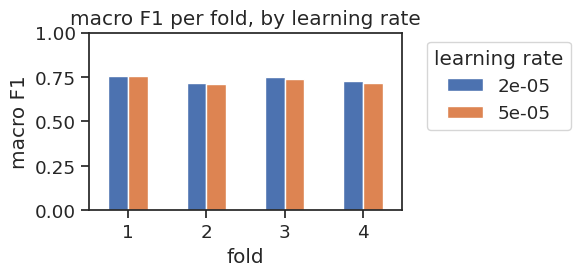

In [15]:
cv_results = pd.DataFrame(results)
print(cv_results.round(5))

# mean and spread of macro-F1 for each learning rate
summary = (cv_results
           .groupby("learning_rate")["macro_f1"]
           .agg(["mean", "std"])
           .round(5))
print("\nmacro-F1 by learning rate:")
print(summary)

best_lr = summary["mean"].idxmax()
print(f"\nBest learning rate by mean macro-F1: {best_lr}")

# picture: one bar per fold, grouped by learning rate
ax = (cv_results
      .pivot(index="fold", columns="learning_rate", values="macro_f1")
      .plot(kind="bar", figsize=(6, 3), rot=0, ylim=(0, 1)))
ax.set_ylabel("macro F1")
ax.set_title("macro F1 per fold, by learning rate")
ax.legend(title="learning rate", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Reading the result

- Prefer the learning rate with the higher **mean** macro-F1 - but only trust that choice if its lead is bigger than the fold-to-fold **standard deviation**. Otherwise the two are within noise and either is fine.
- A large spread for one setting is itself a warning: that configuration is sensitive to which tweets it happens to see.

---

## Train the final model and evaluate it once on the test set

We now train on **all 2000** fine-tuning tweets, using the learning rate cross-validation preferred (`best_lr`), and judge the model **once** on the untouched test set.

In [16]:
# Train one final model on ALL 2000 fine-tuning tweets from our sampled subset, with the learning rate CV preferred.
# train_dataset was already tokenized further up, so we reuse it directly.
# Note we don't test the performance against the validation set here, we just optimise for training loss (you could change this, but no longer once you have tested against the test set, since that would be cheating).
final_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(id2label)
).to(device_name)

final_args = TrainingArguments(
    output_dir=os.path.join(project_dir, "training_checkpoints"),
    num_train_epochs=2,                 # same as the cross-validation runs
    per_device_train_batch_size=8,      # you could try batch_size_grid = [8, 16, 32]
    learning_rate=best_lr,              # <-- chosen by cross-validation
    weight_decay=0.01,                  # other options: weight_decay_grid = [0.0, 0.01, 0.1]
    save_strategy="no",
    logging_steps=50,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset,
)

trainer.train()

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.727367
100,0.624193
150,0.615242
200,0.600231
250,0.560987
300,0.351386
350,0.370944
400,0.360986
450,0.318109
500,0.373433


TrainOutput(global_step=500, training_loss=0.49028783226013184, metrics={'train_runtime': 85.6647, 'train_samples_per_second': 46.694, 'train_steps_per_second': 5.837, 'total_flos': 169691930448000.0, 'train_loss': 0.49028783226013184, 'epoch': 2.0})

#### Bonus: Are you curious how learning rates work? [Try them out](https://playground.tensorflow.org/#activation=relu&regularization=L2&batchSize=8&dataset=xor&regDataset=reg-plane&learningRate=0.01&regularizationRate=0.01&noise=0&networkShape=2&seed=0.96034&showTestData=false&discretize=true&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) in TensorFlow Playground!


### Model Finalization: From Cross-Validation to Production

**Note:** We used a subset of the data for this cross-validation exercise.

**Consider:**
- What would happen if we used the full dataset?
- What about other parameters? Think of warmup_ratio (f.e. [0.0, 0.05, 0.1]), weight decay, or batch size.
- What settings would you use to fine-tune the final model to classify data beyond the human coded training-validation-test set?
- Which part of the data would you allocate for this?

**💡 Try it out:**
- Retrain your model using the full dataset with your chosen settings. How do the performance metrics change compared to the cross-validation results?

In [17]:
#Your final model

## Save the final model

Saved to `save_directory` (in your Google Drive on Colab, so it survives the session).

In [18]:
trainer.save_model(save_directory)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Evaluate the final model on the test set

This is the first and only time we use the test set.

In [19]:
predicted = trainer.predict(test_dataset)
predicted_label_ids = predicted.predictions.argmax(-1)

predicted_labels = [id2label[i] for i in predicted_label_ids]
true_labels      = [id2label[i] for i in y_test]

print(classification_report(true_labels, predicted_labels))

               precision    recall  f1-score   support

non-offensive       0.85      0.93      0.89       620
    offensive       0.76      0.57      0.65       240

     accuracy                           0.83       860
    macro avg       0.80      0.75      0.77       860
 weighted avg       0.82      0.83      0.82       860

